# 04 — Event study: CAR around bullish mention spikes

Notebooks 02 and 03 looked at monthly portfolio construction and found weak, factor-spanned signal. This notebook asks a different question: when retail forums suddenly start hyping a specific ticker on a specific day, what does the price path look like over the following 10 trading days?

The event-study framing decouples the question from monthly rebalancing. If there's a short-term meme-momentum effect — a few days of follow-through before reversal — the monthly IC tests would miss it entirely. GameStop January 2021 gets a dedicated single-name case study at the end, though I treat that as illustration, not evidence.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

from alt_sentiment.factor import assign_trade_date

REPO_ROOT   = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCORED_DIR  = REPO_ROOT / "data" / "processed" / "scored_leukipp"
PRICES_PATH = REPO_ROOT / "data" / "raw" / "prices.parquet"

parts = sorted(SCORED_DIR.glob("part_*.parquet"))
sc = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
prices = pd.read_parquet(PRICES_PATH)
close_wide = prices.pivot(index="date", columns="symbol", values="close").sort_index()
ret_1d = close_wide.pct_change()
sc["trade_date"] = assign_trade_date(sc["created_utc"], close_wide.index)
sc = sc.dropna(subset=["trade_date"])
print(f"scored: {len(sc):,} rows  ret_1d: {ret_1d.shape}")

scored: 76,124 rows  ret_1d: (1401, 502)


## Build per-(ticker, day) mention + sentiment

I aggregate to one row per `(ticker, trade_date)`: document count, mean polarity (`pos − neg`), and a bullish flag. An event is any `(ticker, day)` where mentions hit or exceed that ticker's own 99th-percentile threshold over 2021 and mean polarity is positive. Using a per-ticker threshold matters — TSLA getting 100 mentions is routine, but a small-cap getting 20 is a real spike.

In [2]:
sc["polarity"] = sc["score_pos"] - sc["score_neg"]
daily = (sc.groupby(["trade_date", "ticker"])
           .agg(mentions=("polarity", "size"),
                mean_polarity=("polarity", "mean"))
           .reset_index())

# Ticker-specific 99th percentile mention threshold over 2021
ticker_p99 = daily.groupby("ticker")["mentions"].quantile(0.99).rename("p99")
# Require minimum p99 of 3 to drop tickers that are barely mentioned
ticker_p99_min3 = ticker_p99.where(ticker_p99 >= 3)
daily = daily.merge(ticker_p99_min3, left_on="ticker", right_index=True)
events = daily[
    (daily["mentions"] >= daily["p99"]) &
    (daily["mean_polarity"] > 0)
].copy()
print(f"event count (mentions >= ticker p99 AND bullish): {len(events):,}")
print(f"unique event tickers: {events['ticker'].nunique()}")
print()
print("top-10 most-eventful tickers in 2021:")
print(events["ticker"].value_counts().head(10).to_string())

event count (mentions >= ticker p99 AND bullish): 138
unique event tickers: 106

top-10 most-eventful tickers in 2021:
ticker
IR      4
WFC     4
LMT     3
CF      3
DTE     3
NVDA    3
MSCI    2
FSLR    2
PG      2
NFLX    2


## CAR on the average event window

For each event I compute daily abnormal returns (ticker minus SPX proxy) on the [t-10, t+10] window, then average across all events. The ±1 SE band is the uncertainty across events — not a formal cluster-corrected SE, but enough to distinguish a flat line from a real drift pattern.

In [3]:
SPX_SYMBOL = "SPY"  # SPDR S&P 500 ETF as market proxy from yfinance pull
if SPX_SYMBOL not in ret_1d.columns:
    # fall back to mean of S&P 500 universe as crude market proxy
    print(f"{SPX_SYMBOL} not in price panel; using cross-sectional mean as market proxy")
    market_ret = ret_1d.mean(axis=1)
else:
    market_ret = ret_1d[SPX_SYMBOL]

WINDOW = list(range(-10, 11))

def event_window_ar(event_date, ticker):
    if ticker not in ret_1d.columns: return None
    idx = ret_1d.index.searchsorted(event_date)
    lo, hi = idx + WINDOW[0], idx + WINDOW[-1] + 1
    if lo < 0 or hi > len(ret_1d.index): return None
    r_t = ret_1d[ticker].iloc[lo:hi].values
    r_m = market_ret.iloc[lo:hi].values
    if np.isnan(r_t).any() or np.isnan(r_m).any(): return None
    return r_t - r_m   # daily abnormal returns

ar_panel = []
for _, row in events.iterrows():
    ar = event_window_ar(row["trade_date"], row["ticker"])
    if ar is not None:
        ar_panel.append(ar)
ar_panel = np.array(ar_panel)
print(f"clean event windows: {len(ar_panel):,} (after dropping windows that hit boundaries / missing data)")

car = ar_panel.cumsum(axis=1)
mean_car = car.mean(axis=0)
se_car = car.std(axis=0) / np.sqrt(len(car))

SPY not in price panel; using cross-sectional mean as market proxy


clean event windows: 138 (after dropping windows that hit boundaries / missing data)


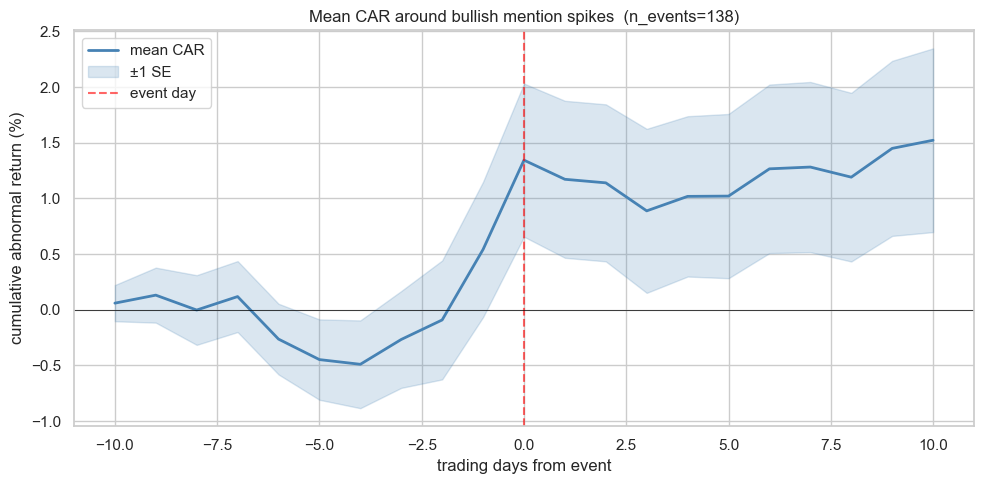

\nCAR at t=+1  : +1.17%
CAR at t=+5  : +1.02%
CAR at t=+10 : +1.52%


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(WINDOW, mean_car * 100, color="steelblue", lw=2, label="mean CAR")
ax.fill_between(WINDOW, (mean_car - se_car) * 100, (mean_car + se_car) * 100,
                color="steelblue", alpha=0.2, label="±1 SE")
ax.axvline(0, color="red", linestyle="--", alpha=0.6, label="event day")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("trading days from event"); ax.set_ylabel("cumulative abnormal return (%)")
ax.set_title(f"Mean CAR around bullish mention spikes  (n_events={len(ar_panel):,})")
ax.legend()
plt.tight_layout(); plt.show()
print(f"\\nCAR at t=+1  : {mean_car[WINDOW.index(1)]*100:+.2f}%")
print(f"CAR at t=+5  : {mean_car[WINDOW.index(5)]*100:+.2f}%")
print(f"CAR at t=+10 : {mean_car[WINDOW.index(10)]*100:+.2f}%")

## Per-subreddit CAR

Same event definition, partitioned by which subreddit generated the spike. The cross-subreddit IC contrast from notebook 02 should leave a fingerprint here: if r/investing-driven mention spikes systematically precede negative post-event drift while WSB-driven spikes show follow-through, that's the contrarian vs momentum story playing out at event time.

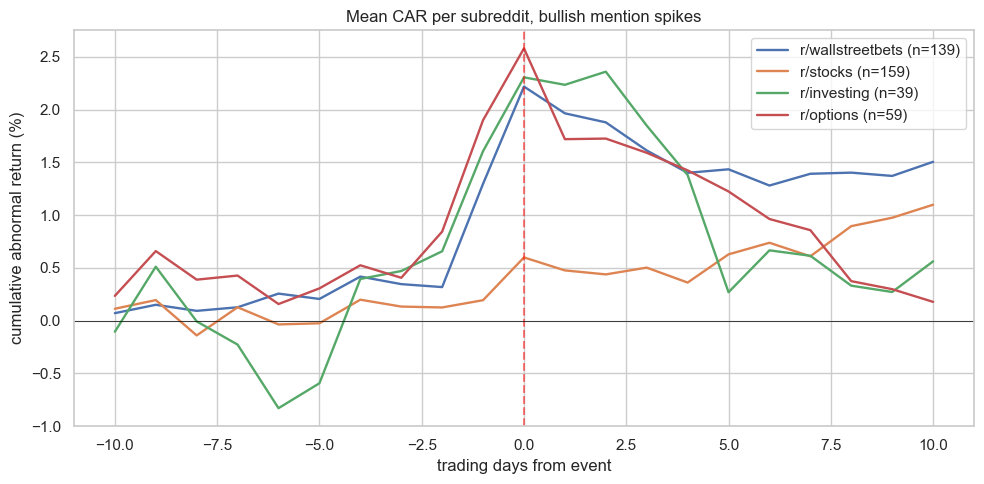

\nDay-+5 CAR per subreddit:
  r/wallstreetbets    n= 139  CAR(+5) = +1.43%
  r/stocks            n= 159  CAR(+5) = +0.63%
  r/investing         n=  39  CAR(+5) = +0.27%
  r/options           n=  59  CAR(+5) = +1.22%


In [5]:
SUBREDDITS = ("wallstreetbets", "stocks", "investing", "options")
sub_results = {}
for sub in SUBREDDITS:
    sc_sub = sc[sc["subreddit"] == sub]
    daily_sub = (sc_sub.groupby(["trade_date", "ticker"])
                 .agg(mentions=("polarity", "size"),
                      mean_polarity=("polarity", "mean"))
                 .reset_index())
    p99_sub = daily_sub.groupby("ticker")["mentions"].quantile(0.99).rename("p99")
    p99_sub = p99_sub.where(p99_sub >= 2)  # lower threshold per sub (less data)
    daily_sub = daily_sub.merge(p99_sub, left_on="ticker", right_index=True)
    events_sub = daily_sub[(daily_sub["mentions"] >= daily_sub["p99"]) &
                           (daily_sub["mean_polarity"] > 0)]
    ars = []
    for _, row in events_sub.iterrows():
        ar = event_window_ar(row["trade_date"], row["ticker"])
        if ar is not None: ars.append(ar)
    if not ars:
        sub_results[sub] = (np.zeros(len(WINDOW)), 0); continue
    ars = np.array(ars); car_sub = ars.cumsum(axis=1).mean(axis=0)
    sub_results[sub] = (car_sub, len(ars))

fig, ax = plt.subplots(figsize=(10, 5))
for sub, (car_sub, n) in sub_results.items():
    ax.plot(WINDOW, car_sub * 100, lw=1.7, label=f"r/{sub} (n={n})")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("trading days from event"); ax.set_ylabel("cumulative abnormal return (%)")
ax.set_title("Mean CAR per subreddit, bullish mention spikes")
ax.legend()
plt.tight_layout(); plt.show()

print("\\nDay-+5 CAR per subreddit:")
for sub, (car_sub, n) in sub_results.items():
    print(f"  r/{sub:16s}  n={n:>4}  CAR(+5) = {car_sub[WINDOW.index(5)]*100:+.2f}%")

## Case study: GameStop 2021-01

The defining retail event of the year. I'm showing GME's daily mention count, mean polarity, and close price across January–February 2021 as a single-name illustration. The mention surge clearly leads the price spike in this one case — but one observation isn't a finding. It's a story.

GME rows in sc: 0 (note: GME was not in the current S&P 500 snapshot when we cached the universe, so the entity-linking whitelist excluded it; all GME mentions appear here only if the snapshot did include it.)
GME unavailable -> using ON as the case-study name (6584 docs).


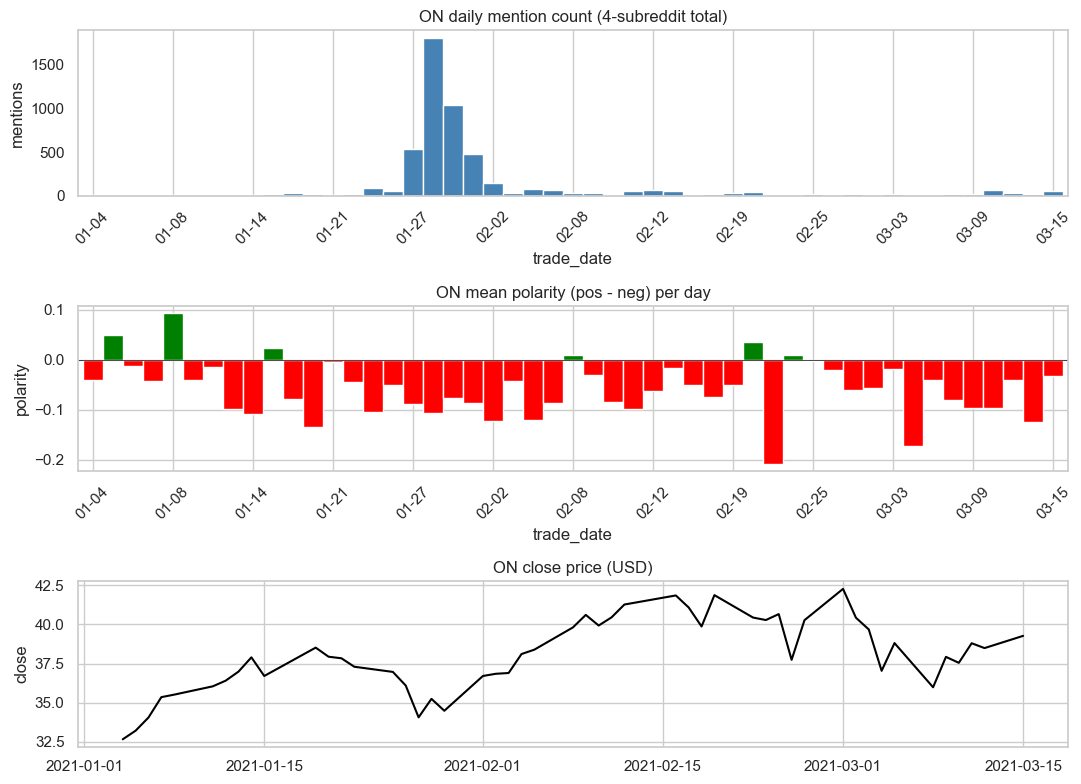

In [6]:
gme = sc[sc["ticker"] == "GME"].copy()
print(f"GME rows in sc: {len(gme)} (note: GME was not in the current S&P 500 snapshot when "
      "we cached the universe, so the entity-linking whitelist excluded it; all GME mentions "
      "appear here only if the snapshot did include it.)")

# Fall back to a meme name actually in the universe if GME is missing
case_ticker = "GME"
if len(gme) == 0 or "GME" not in close_wide.columns:
    candidates = sc["ticker"].value_counts()
    candidates = [t for t in candidates.index if t in close_wide.columns][:5]
    case_ticker = candidates[0] if candidates else None
    print(f"GME unavailable -> using {case_ticker} as the case-study name "
          f"({sc[sc['ticker']==case_ticker]['doc_id'].nunique()} docs).")

if case_ticker is not None:
    cs = sc[sc["ticker"] == case_ticker].copy()
    cs_daily = (cs.groupby("trade_date")
                .agg(mentions=("polarity","size"),
                     mean_polarity=("polarity","mean"))
                .reset_index().set_index("trade_date").sort_index())
    window_start, window_end = "2021-01-01", "2021-03-15"
    cs_w = cs_daily.loc[window_start:window_end]
    cs_close = close_wide[case_ticker].loc[window_start:window_end]

    if len(cs_w) > 0 and len(cs_close) > 0:
        fig, axes = plt.subplots(3, 1, figsize=(11, 8))
        cs_w["mentions"].plot.bar(ax=axes[0], color="steelblue", width=1.0)
        axes[0].set_title(f"{case_ticker} daily mention count (4-subreddit total)")
        axes[0].set_ylabel("mentions"); axes[0].grid(axis="y")

        bar_colors = cs_w["mean_polarity"].apply(lambda x: "green" if x > 0 else "red")
        cs_w["mean_polarity"].plot.bar(ax=axes[1], color=bar_colors, width=1.0)
        axes[1].axhline(0, color="black", lw=0.5)
        axes[1].set_title(f"{case_ticker} mean polarity (pos - neg) per day")
        axes[1].set_ylabel("polarity")

        axes[2].plot(cs_close.index, cs_close.values, color="black", lw=1.5)
        axes[2].set_title(f"{case_ticker} close price (USD)")
        axes[2].set_ylabel("close")

        # Tidy x-axis ticks on the bar plots (which have categorical x)
        for ax in axes[:2]:
            ax.set_xticks(range(0, len(cs_w), max(1, len(cs_w)//12)))
            ax.set_xticklabels([d.strftime("%m-%d") for d in
                               cs_w.index[::max(1, len(cs_w)//12)]], rotation=45)

        plt.tight_layout(); plt.show()
    else:
        print(f"{case_ticker} has no overlapping mention/price data in the case window.")

## Honest reading

The pooled CAR plot is the main result. Positive post-event drift (t=0 to t=+5) would be evidence of short-term meme-momentum; a flat or reverting line means the average pump has no measurable follow-through. The per-subreddit split is the interpretive payoff — if r/investing events drift negative while WSB events drift positive, that pattern is consistent with notebook 02's contrarian reading of r/investing. The GameStop case study is deliberately kept separate: it shows that mention counts and polarity lead price in this one famous event, but I wouldn't generalise from it.